In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'D:\Fifa Project\ball data\fifa_world_cup_enhanced_1974_2022.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (43, 38)

Columns: ['match_id', 'year', 'date', 'stage', 'home_team', 'away_team', 'home_goals', 'away_goals', 'winner', 'goal_difference', 'total_goals', 'home_xg', 'away_xg', 'possession_home', 'possession_away', 'shots_home', 'shots_away', 'shots_ontarget_home', 'shots_ontarget_away', 'corners_home', 'corners_away', 'fouls_home', 'fouls_away', 'yellow_cards_home', 'yellow_cards_away', 'red_cards_home', 'red_cards_away', 'attendance', 'venue', 'city', 'referee', 'home_goals_detail', 'away_goals_detail', 'penalty_shootout', 'penalty_home', 'penalty_away', 'tournament_format', 'host_nations']

First 5 rows:


,match_id,year,date,stage,home_team,away_team,home_goals,away_goals,winner,goal_difference,...,venue,city,referee,home_goals_detail,away_goals_detail,penalty_shootout,penalty_home,penalty_away,tournament_format,host_nations
0,WC-1974-001,1974,1974-06-13,Group 1,Brazil,Yugoslavia,0,0,Draw,0,...,Waldstadion,Frankfurt,Károly Palotai (Hungary),NaN,Jovan Aćimović (60'),No,NaN,NaN,16,West Germany
1,WC-1974-038,1974,1974-07-07,Final,West Germany,Netherlands,2,1,West Germany,1,...,Olympiastadion,Munich,John Taylor (England),"Paul Breitner (25' pen), Gerd Müller (43')",Johan Neeskens (2' pen),No,NaN,NaN,16,West Germany
2,WC-1974-008,1974,1974-06-18,Group 2,Yugoslavia,Zaire,9,0,Yugoslavia,9,...,Parkstadion,Gelsenkirchen,Omar Delgado (Colombia),"Dušan Bajević (8', 30', 81'), Dragan Džajić (1...",NaN,No,NaN,NaN,16,West Germany
3,WC-1974-012,1974,1974-06-22,Group A,Netherlands,Brazil,2,0,Netherlands,2,...,Westfalenstadion,Dortmund,Kurt Tschenscher (West Germany),"Johan Neeskens (50'), Johan Cruyff (65')",NaN,No,NaN,NaN,16,West Germany
4,WC-1978-038,1978,1978-06-25,Final,Argentina,Netherlands,3,1,Argentina,2,...,Estadio Monumental,Buenos Aires,Sergio Gonella (Italy),"Mario Kempes (38', 105'), Daniel Bertoni (115')",Dirk Nanninga (82'),Yes (AET),NaN,NaN,16,Argentina


In [3]:
# Basic info about the dataset
print("=== BASIC INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
print(df[['home_goals', 'away_goals', 'total_goals', 'possession_home', 'shots_home', 'shots_away']].describe())

=== BASIC INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             43 non-null     str    
 1   year                 43 non-null     int64  
 2   date                 43 non-null     str    
 3   stage                43 non-null     str    
 4   home_team            43 non-null     str    
 5   away_team            43 non-null     str    
 6   home_goals           43 non-null     int64  
 7   away_goals           43 non-null     int64  
 8   winner               43 non-null     str    
 9   goal_difference      43 non-null     int64  
 10  total_goals          43 non-null     int64  
 11  home_xg              43 non-null     float64
 12  away_xg              43 non-null     float64
 13  possession_home      43 non-null     int64  
 14  possession_away      43 non-null     int64  
 15  shots_home           43 non-null  

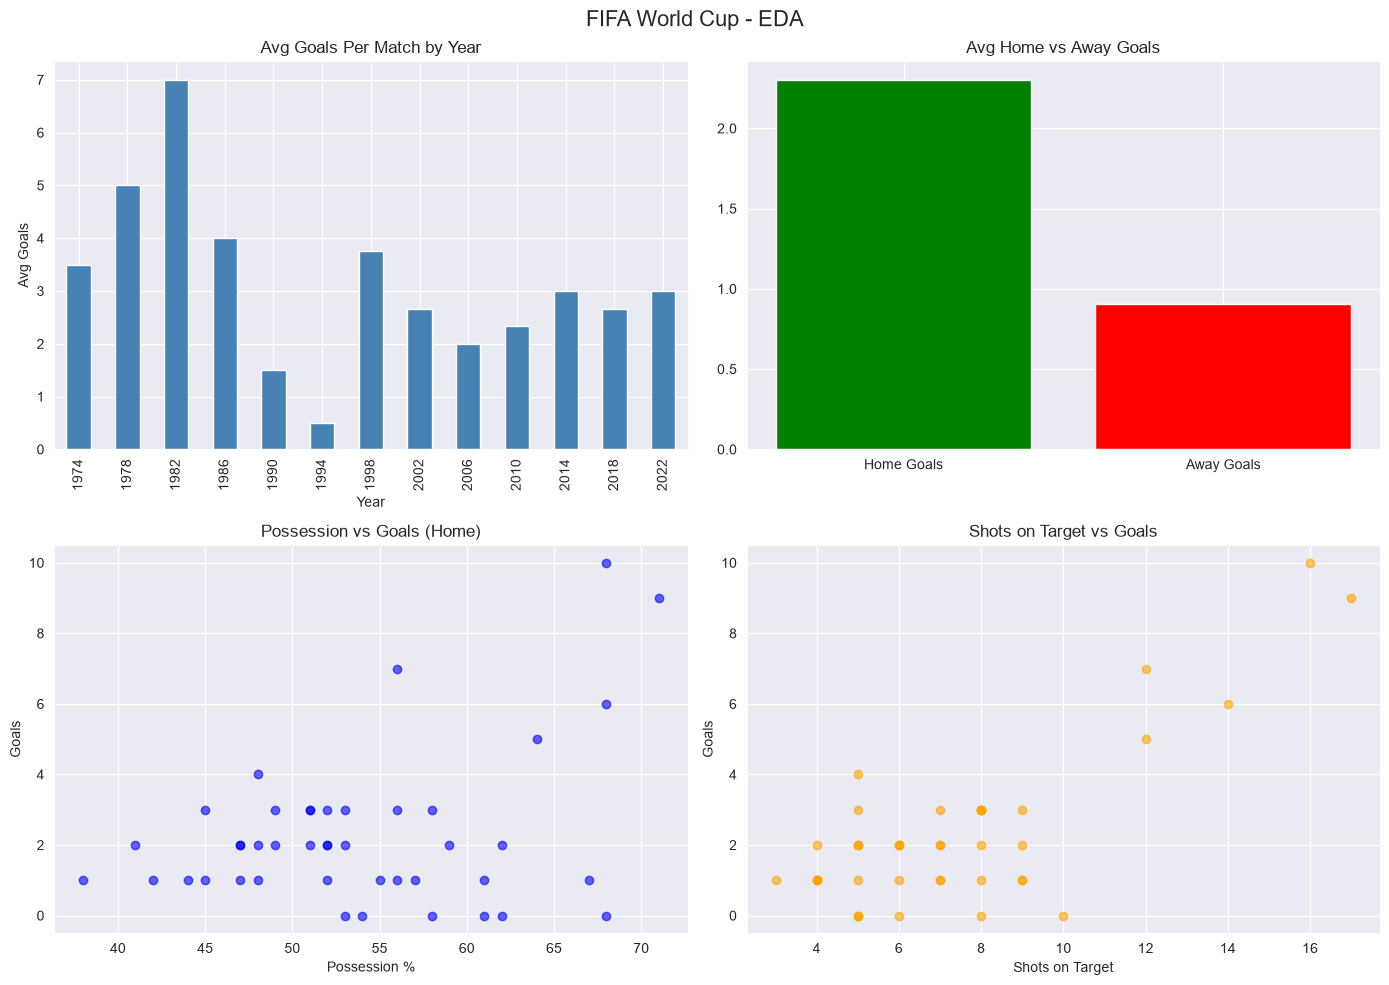

In [4]:
# Set style
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FIFA World Cup - EDA', fontsize=16)

# 1. Total goals per year
df.groupby('year')['total_goals'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Avg Goals Per Match by Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Avg Goals')

# 2. Home vs Away goals
axes[0,1].bar(['Home Goals', 'Away Goals'], 
               [df['home_goals'].mean(), df['away_goals'].mean()], 
               color=['green', 'red'])
axes[0,1].set_title('Avg Home vs Away Goals')

# 3. Possession vs Goals
axes[1,0].scatter(df['possession_home'], df['home_goals'], color='blue', alpha=0.6)
axes[1,0].set_title('Possession vs Goals (Home)')
axes[1,0].set_xlabel('Possession %')
axes[1,0].set_ylabel('Goals')

# 4. Shots on target vs Goals
axes[1,1].scatter(df['shots_ontarget_home'], df['home_goals'], color='orange', alpha=0.6)
axes[1,1].set_title('Shots on Target vs Goals')
axes[1,1].set_xlabel('Shots on Target')
axes[1,1].set_ylabel('Goals')

plt.tight_layout()
plt.show()

In [5]:
# Create target variable - who won?
# 1 = home team won, 0 = draw or away win
df['home_win'] = (df['winner'] == df['home_team']).astype(int)

# Select features for our model
features = [
    'possession_home', 'possession_away',
    'shots_home', 'shots_away',
    'shots_ontarget_home', 'shots_ontarget_away',
    'home_xg', 'away_xg',
    'fouls_home', 'fouls_away',
    'yellow_cards_home', 'yellow_cards_away'
]

X = df[features]
y = df['home_win']

print("Features shape:", X.shape)
print("Target value counts:\n", y.value_counts())

Features shape: (43, 12)
Target value counts:
 home_win
1    32
0    11
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Results
print("\n=== RANDOM FOREST RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training samples: 34
Testing samples: 9

=== RANDOM FOREST RESULTS ===
Accuracy: 0.7777777777777778

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.88      0.88      0.88         8

    accuracy                           0.78         9
   macro avg       0.44      0.44      0.44         9
weighted avg       0.78      0.78      0.78         9



C:\Users\Sachin Raut\AppData\Local\Temp\ipykernel_19112\1983205839.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


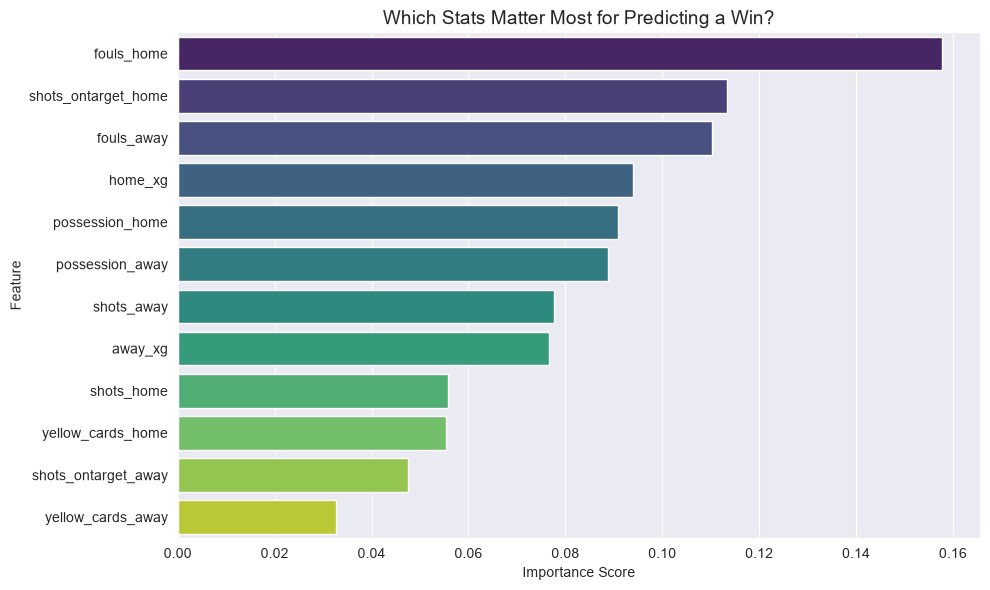


Top 3 most important features:
               feature  importance
8           fouls_home    0.157691
4  shots_ontarget_home    0.113263
9           fouls_away    0.110175


In [7]:
# Feature Importance Chart
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Which Stats Matter Most for Predicting a Win?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(feature_importance.head(3))

In [8]:
def predict_win_probability(possession_home, possession_away, 
                             shots_home, shots_away,
                             shots_ontarget_home, shots_ontarget_away,
                             home_xg, away_xg,
                             fouls_home, fouls_away,
                             yellow_cards_home, yellow_cards_away):
    
    # Create input array
    input_data = pd.DataFrame([[
        possession_home, possession_away,
        shots_home, shots_away,
        shots_ontarget_home, shots_ontarget_away,
        home_xg, away_xg,
        fouls_home, fouls_away,
        yellow_cards_home, yellow_cards_away
    ]], columns=features)
    
    # Get probability
    prob = rf_model.predict_proba(input_data)[0]
    
    print("=== WIN PROBABILITY PREDICTOR ===")
    print(f"Away Team Win Probability: {prob[0]*100:.1f}%")
    print(f"Home Team Win Probability: {prob[1]*100:.1f}%")

# Example: Brazil vs Argentina
print("BRAZIL (home) vs ARGENTINA (away)")
predict_win_probability(
    possession_home=55, possession_away=45,
    shots_home=14, shots_away=10,
    shots_ontarget_home=6, shots_ontarget_away=4,
    home_xg=1.8, away_xg=1.2,
    fouls_home=12, fouls_away=14,
    yellow_cards_home=1, yellow_cards_away=2
)

BRAZIL (home) vs ARGENTINA (away)
=== WIN PROBABILITY PREDICTOR ===
Away Team Win Probability: 53.0%
Home Team Win Probability: 47.0%
